# LSTM 从原理到实践：门控前向、BPTT 与梯度流实验

> 路线：从 RNN 的梯度消失出发 → LSTM 门控公式与参数布局 → 手写前向（对齐 `nn.LSTM`）→ 手写 BPTT（对齐 Autograd）→ 门控动态可视化 → 梯度流对比实验 → 长依赖任务训练 → 多层/双向与 PAD。
>

## 1. 导入依赖与固定随机种子

- 导入 `torch`、`torch.nn`、`torch.nn.functional`、`matplotlib`、`numpy`；
- 固定 `torch.manual_seed(7)` 与 numpy 种子，保证结果可复现；
- 数值核对涉及的浮点张量统一使用 `dtype=torch.float64`，便于观察「手写实现 vs 内置实现」的机器精度级误差。

In [3]:
import math

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

# 固定随机种子，保证结果可复现
torch.manual_seed(7)
np.random.seed(7)

# 统一按 float64：手写实现与内置实现的逐项核对要看到机器精度级误差
DTYPE = torch.float64

plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei"]
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 110

print("torch:", torch.__version__, "| CUDA:", torch.cuda.is_available())

torch: 2.10.0+cu128 | CUDA: True


## 2. 复现 RNN 的梯度消失：梯度范数随距离衰减

RNN 的跨时间梯度是**雅可比连乘**：

$$
\frac{\partial h_t}{\partial h_k} = J_t J_{t-1} \cdots J_{k+1}, \qquad J_t = \mathrm{diag}\!\big(1 - h_t \odot h_t\big)\, W_{hh}, \qquad k < t
$$

取一个长序列（$T=60$），用最后一步的状态构造标量损失，再用 `torch.autograd.grad` 取 $\partial L/\partial h_t$ —— 预期**越早的时间步梯度越小**（连乘衰减 + tanh 饱和）。

t=0 （最早）  梯度范数: 2.226e-08
t=59 （最后） 梯度范数: 4.000e+00


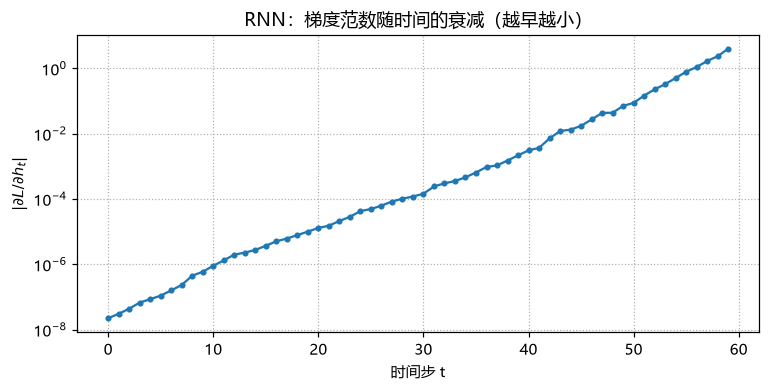

In [4]:
# 长序列 RNN：用最后一步的损失，回看各时间步 h_t 的梯度范数
T_long, hidden_rnn = 60, 16

torch.manual_seed(7)
W_xh = torch.randn(hidden_rnn, 1, dtype=DTYPE) * 0.5
W_hh = torch.randn(hidden_rnn, hidden_rnn, dtype=DTYPE) * 0.2   # 缩小循环权重，构造梯度衰减示例
b_h = torch.zeros(hidden_rnn, dtype=DTYPE)

x_seq = (torch.randn(T_long, 1, 1, dtype=DTYPE) * 0.5).requires_grad_()

h = torch.zeros(1, hidden_rnn, dtype=DTYPE)
h_states = []
for t in range(T_long):
    h = torch.tanh(x_seq[t] @ W_xh.T + h @ W_hh.T + b_h)
    h_states.append(h)

loss = h_states[-1].sum()
grads = torch.autograd.grad(loss, h_states)          # ∂loss/∂h_t，逐个时间步
grad_norms = torch.tensor([g.norm().item() for g in grads])

print(f"t=0 （最早）  梯度范数: {grad_norms[0]:.3e}")
print(f"t={T_long - 1} （最后） 梯度范数: {grad_norms[-1]:.3e}")

plt.figure(figsize=(8, 3.5))
plt.semilogy(grad_norms.numpy(), marker=".")
plt.xlabel("时间步 t")
plt.ylabel(r"$|\partial L/\partial h_t|$")
plt.title("RNN：梯度范数随时间的衰减（越早越小）")
plt.grid(True, which="both", ls=":")
plt.show()

## 3. LSTM 门控公式与 `nn.LSTM` 参数布局

### 3.1 前向公式

四个门 + 两个状态（$h_t$ 对外输出；$c_t$ 是内部记忆，也就是"梯度高速公路"）：

$$
i_t = \sigma\!\big(W_{ii} x_t + b_{ii} + W_{hi} h_{t-1} + b_{hi}\big)
$$

$$
f_t = \sigma\!\big(W_{if} x_t + b_{if} + W_{hf} h_{t-1} + b_{hf}\big)
$$

$$
g_t = \tanh\!\big(W_{ig} x_t + b_{ig} + W_{hg} h_{t-1} + b_{hg}\big)
$$

$$
o_t = \sigma\!\big(W_{io} x_t + b_{io} + W_{ho} h_{t-1} + b_{ho}\big)
$$

$$
c_t = f_t \odot c_{t-1} + i_t \odot g_t, \qquad h_t = o_t \odot \tanh(c_t), \qquad h_0 = c_0 = \mathbf{0}
$$

核心是 $c_t$ 的**加法更新**。固定当前门值、只看从 $c_{t-1}$ 到 $c_t$ 的直接路径时，$\partial c_t/\partial c_{t-1}=\mathrm{diag}(f_t)$，梯度不必在每一步都直接乘循环权重矩阵（对比第 2 节的 $J_t$ 连乘）。完整梯度仍包含经 $h_{t-1}$ 影响各门的间接路径，而且连续的 $\prod f_t$ 仍可能衰减。

### 3.2 PyTorch 参数布局

`nn.LSTM` 把四个门的权重**按 `i、f、g、o` 顺序拼接**：

- `weight_ih_l0`：$(4d,\, n)$（输入侧权重，四段拼接）
- `weight_hh_l0`：$(4d,\, d)$（循环侧权重）
- `bias_ih_l0` / `bias_hh_l0`：$(4d,)$，前向中相加（如 $b_{ii} + b_{hi}$）
- 返回 `output, (h_n, c_n)`：`output` 为最后一层所有时间步；`h_n`、`c_n` 第一维是 层数×方向数

In [5]:
# 观察 nn.LSTM 的参数布局：四组门按 i、f、g、o 的顺序拼接
B, T, input_size, hidden_size = 2, 5, 4, 3

probe = nn.LSTM(input_size, hidden_size, batch_first=True).to(DTYPE)
for name, p in probe.named_parameters():
    print(f"{name:16s} {tuple(p.shape)}")

print("\nweight_ih_l0 按四段门拆开：")
for name, seg in zip(["i", "f", "g", "o"], probe.weight_ih_l0.detach().chunk(4, dim=0)):
    print(f"  {name}: {tuple(seg.shape)}")

weight_ih_l0     (12, 4)
weight_hh_l0     (12, 3)
bias_ih_l0       (12,)
bias_hh_l0       (12,)

weight_ih_l0 按四段门拆开：
  i: (3, 4)
  f: (3, 4)
  g: (3, 4)
  o: (3, 4)


## 4. 初始化参数并与 `nn.LSTM` 对齐

随机初始化 $W_{ih} \in \mathbb{R}^{4d \times n}$、$W_{hh} \in \mathbb{R}^{4d \times d}$、$b_{ih},\, b_{hh} \in \mathbb{R}^{4d}$（`float64`），原地拷贝进 `nn.LSTM`。

这样**手写前向与 PyTorch 前向共用同一组参数**，第 6 节的逐项核对才有意义（否则比的是两组不同权重）。

In [6]:
torch.manual_seed(7)
num_gates = 4

# 与 nn.LSTM 相同的布局：(4d, n) / (4d, d)，四段依次为 i、f、g、o
W_ih = torch.randn(num_gates * hidden_size, input_size, dtype=DTYPE) * 0.5
W_hh = torch.randn(num_gates * hidden_size, hidden_size, dtype=DTYPE) * 0.5
b_ih = torch.randn(num_gates * hidden_size, dtype=DTYPE) * 0.5
b_hh = torch.randn(num_gates * hidden_size, dtype=DTYPE) * 0.5

x = torch.randn(B, T, input_size, dtype=DTYPE)

lstm = nn.LSTM(input_size, hidden_size, batch_first=True).to(DTYPE)
with torch.no_grad():
    lstm.weight_ih_l0.copy_(W_ih)
    lstm.weight_hh_l0.copy_(W_hh)
    lstm.bias_ih_l0.copy_(b_ih)
    lstm.bias_hh_l0.copy_(b_hh)

print("已对齐：手写实现与 nn.LSTM 共用同一组参数")

已对齐：手写实现与 nn.LSTM 共用同一组参数


## 5. 手写 LSTM 前向递推

按公式循环时间步：

1. `gates = x_t @ W_ih.T + h_{t-1} @ W_hh.T + b_ih + b_hh`，形状 $(B,\ 4d)$；
2. 按 `i、f、g、o` 切成四段：`i / f / o` 过 `sigmoid`，`g` 过 `tanh`；
3. $c_t = f \odot c_{t-1} + i \odot g$，$h_t = o \odot \tanh(c_t)$；
4. 保存每一步的 $c$、$h$ 与四个门值，供第 7 节 BPTT 和第 8 节可视化使用。

In [5]:
# 手写前向：严格按公式循环时间步
h = torch.zeros(B, hidden_size, dtype=DTYPE)   # h_0 = 0
c = torch.zeros(B, hidden_size, dtype=DTYPE)   # c_0 = 0

h_seq, c_seq, gates_seq = [], [], []
for t in range(T):
    gates = x[:, t] @ W_ih.T + h @ W_hh.T + b_ih + b_hh   # (B, 4d)
    i_t, f_t, g_t, o_t = gates.chunk(4, dim=1)

    i_t, f_t, o_t = torch.sigmoid(i_t), torch.sigmoid(f_t), torch.sigmoid(o_t)
    g_t = torch.tanh(g_t)

    c = f_t * c + i_t * g_t            # 加法路径：c 的梯度可以直接流回早期时间步
    h = o_t * torch.tanh(c)

    h_seq.append(h)
    c_seq.append(c)
    gates_seq.append((i_t, f_t, g_t, o_t))

manual_output = torch.stack(h_seq, dim=1)   # (B, T, d)
manual_c_last = c_seq[-1]                   # (B, d)

print("手写 output:", tuple(manual_output.shape), "| c_T:", tuple(manual_c_last.shape))

手写 output: (2, 5, 3) | c_T: (2, 3)


## 6. 与 `nn.LSTM` 前向结果逐项核对

同一输入、同一组参数，分别用手写循环和 `nn.LSTM` 跑一遍：

- `output` 应逐元素一致（$10^{-12}$ 容差内）；
- 手写的 $h_T$、$c_T$ 应分别等于 `h_n[-1]`、`c_n[-1]`；
- 单层单向且无 PAD 时，`output[:, -1]` 与 `h_n[-1]` 相等。

In [6]:
with torch.no_grad():
    torch_output, (torch_h_n, torch_c_n) = lstm(x)

print("手写 output == nn.LSTM output：", torch.allclose(manual_output, torch_output, atol=1e-12))
print("手写 h_T   == nn.LSTM h_n[-1]：", torch.allclose(manual_output[:, -1], torch_h_n[-1], atol=1e-12))
print("手写 c_T   == nn.LSTM c_n[-1]：", torch.allclose(manual_c_last, torch_c_n[-1], atol=1e-12))
print("output[:, -1] == h_n[-1]：     ", torch.allclose(torch_output[:, -1], torch_h_n[-1], atol=1e-12))

手写 output == nn.LSTM output： True
手写 h_T   == nn.LSTM h_n[-1]： True
手写 c_T   == nn.LSTM c_n[-1]： True
output[:, -1] == h_n[-1]：      True


## 7. 手写 LSTM 的 BPTT，与 Autograd 对比

记 $\delta h_t = \partial L/\partial h_t$、$\delta c_t = \partial L/\partial c_t$，从 $t=T$ 往回递推：

$$
\delta h_t = W_{hy}^{\top} e_t + W_{hh}^{\top}\delta a_{t+1}
$$

$$
\delta c_t = \underbrace{\delta h_t \odot o_t \odot \big(1 - \tanh^2 c_t\big)}_{\text{经 } h_t = o_t \odot \tanh(c_t)} + \underbrace{\delta c_{t+1} \odot f_{t+1}}_{\text{未来沿 } c \text{ 回传}}
$$

四个门的预激活误差（拼接顺序 `i、f、g、o`）：

$$
\delta o_t = \delta h_t \odot \tanh c_t \odot o_t (1-o_t), \qquad
\delta f_t = \delta c_t \odot c_{t-1} \odot f_t (1-f_t)
$$

$$
\delta i_t = \delta c_t \odot g_t \odot i_t (1-i_t), \qquad
\delta g_t = \delta c_t \odot i_t \odot (1-g_t^2)
$$

把 $\delta a_t = [\delta i_t; \delta f_t; \delta g_t; \delta o_t]$ 拼好，参数梯度沿时间累加，例如 $\partial L/\partial W_{ih} = \sum_t \delta a_t\, x_t^{\top}$。

**关键是 cell state 的直接回传项 $\delta c_{t+1}\odot f_{t+1}$**：这条路径不直接乘循环权重矩阵，也不经过新的 tanh 导数，因此通常比普通 RNN 的雅可比连乘更稳定。但完整的 $\delta c_t$ 仍包含输出路径中的 tanh 导数，且 $\prod f_t$ 仍可能衰减。

In [7]:
# 输出层：logits = h_t @ W_hy.T + b_y（沿用 RNN 那套写法）
num_classes = 2
torch.manual_seed(11)
W_hy = torch.randn(num_classes, hidden_size, dtype=DTYPE, requires_grad=True)
b_y = torch.randn(num_classes, dtype=DTYPE, requires_grad=True)
targets = torch.randint(0, num_classes, (B, T))

# ---------- PyTorch 侧：带图前向 + 交叉熵 + backward ----------
lstm.zero_grad()
torch_output2, _ = lstm(x)
logits = torch_output2 @ W_hy.T + b_y
loss = F.cross_entropy(logits.reshape(-1, num_classes), targets.reshape(-1), reduction="sum")
loss.backward()

autograd_grads = {
    "W_ih": lstm.weight_ih_l0.grad.detach().clone(),
    "W_hh": lstm.weight_hh_l0.grad.detach().clone(),
    "b_ih": lstm.bias_ih_l0.grad.detach().clone(),
    "b_hh": lstm.bias_hh_l0.grad.detach().clone(),
    "W_hy": W_hy.grad.detach().clone(),
    "b_y": b_y.grad.detach().clone(),
}

# ---------- 手写 BPTT：沿时间反向维护 dh、dc 两条通路 ----------
with torch.no_grad():
    one_hot = F.one_hot(targets, num_classes=num_classes).to(DTYPE)
    errors = torch.softmax(logits.detach(), dim=-1) - one_hot    # e_t = ŷ_t - y_t

    dW_ih = torch.zeros_like(W_ih)
    dW_hh = torch.zeros_like(W_hh)
    db_ih = torch.zeros_like(b_ih)
    db_hh = torch.zeros_like(b_hh)
    dW_hy = torch.zeros_like(W_hy)
    db_y = torch.zeros_like(b_y)

    dh_future = torch.zeros(B, hidden_size, dtype=DTYPE)
    dc_future = torch.zeros(B, hidden_size, dtype=DTYPE)

    for t in reversed(range(T)):
        h_t = manual_output[:, t]
        c_t = c_seq[t]
        h_prev = manual_output[:, t - 1] if t > 0 else torch.zeros_like(h_t)
        c_prev = c_seq[t - 1] if t > 0 else torch.zeros_like(c_t)
        i_t, f_t, g_t, o_t = (gates_seq[t][k] for k in range(4))

        # 输出层
        dW_hy += errors[:, t].T @ h_t
        db_y += errors[:, t].sum(dim=0)

        dh_t = errors[:, t] @ W_hy + dh_future               # δh_t
        th_t = torch.tanh(c_t)
        dc_t = dh_t * o_t * (1 - th_t ** 2) + dc_future      # δc_t

        # 四门预激活误差（顺序 i、f、g、o）
        do_t = dh_t * th_t * o_t * (1 - o_t)
        df_t = dc_t * c_prev * f_t * (1 - f_t)
        di_t = dc_t * g_t * i_t * (1 - i_t)
        dg_t = dc_t * i_t * (1 - g_t ** 2)
        da_t = torch.cat([di_t, df_t, dg_t, do_t], dim=1)    # (B, 4d)

        # 参数梯度（对时间累加）
        dW_ih += da_t.T @ x[:, t]
        dW_hh += da_t.T @ h_prev
        db_ih += da_t.sum(dim=0)
        db_hh += da_t.sum(dim=0)

        # 往更早的时间步传递：h 走 W_hh；c 乘遗忘门 f_t
        dh_future = da_t @ W_hh
        dc_future = dc_t * f_t

manual_grads = {
    "W_ih": dW_ih, "W_hh": dW_hh, "b_ih": db_ih, "b_hh": db_hh,
    "W_hy": dW_hy, "b_y": db_y,
}

print(f"loss = {loss.item():.6f}")
print("手写 BPTT 与 Autograd 的最大绝对误差：")
for name in manual_grads:
    err = (manual_grads[name] - autograd_grads[name]).abs().max().item()
    print(f"  {name:5s}: {err:.3e}")

loss = 7.085615
手写 BPTT 与 Autograd 的最大绝对误差：
  W_ih : 1.665e-16
  W_hh : 2.776e-17
  b_ih : 1.804e-16
  b_hh : 1.943e-16
  W_hy : 9.714e-17
  b_y  : 2.220e-16


## 8. 可视化门控与单元状态的动态

用同一组参数在更长的随机序列（$T=60$）上观察门控行为：

- 四个门的开合（热力图：隐藏单元 × 时间）；
- $c_t$ 的演化：加法写入 + 遗忘门控制的泄漏。

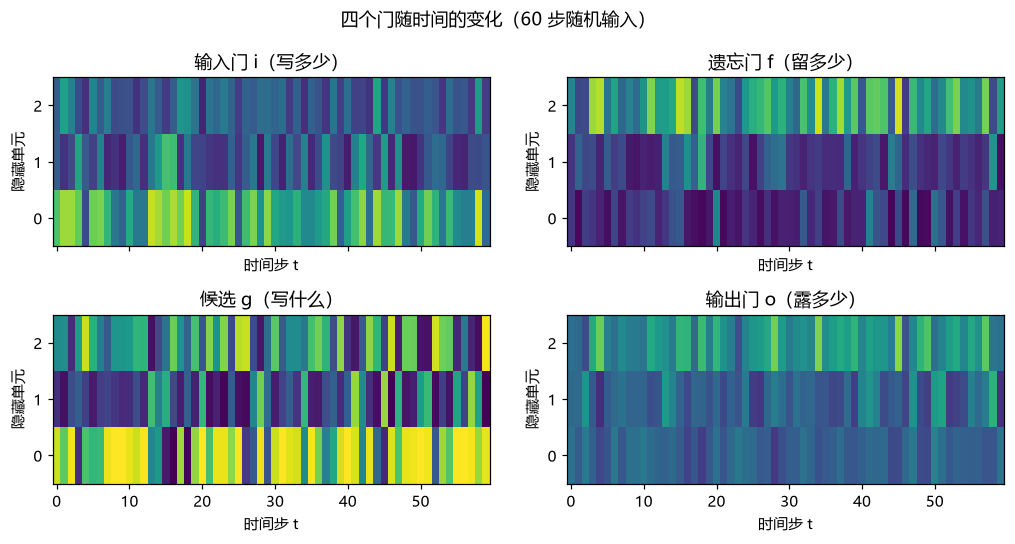

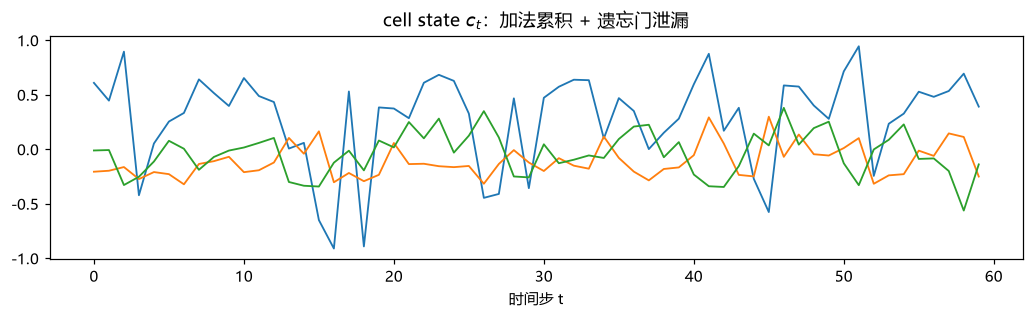

In [8]:
# 同一组参数，在 60 步随机序列上看门控与状态动态
T_vis = 60
torch.manual_seed(3)
x_vis = torch.randn(1, T_vis, input_size, dtype=DTYPE) * 0.8

h = torch.zeros(1, hidden_size, dtype=DTYPE)
c = torch.zeros(1, hidden_size, dtype=DTYPE)
vis = {"i": [], "f": [], "g": [], "o": []}
c_hist = []
for t in range(T_vis):
    gates = x_vis[:, t] @ W_ih.T + h @ W_hh.T + b_ih + b_hh
    i_t, f_t, g_t, o_t = gates.chunk(4, dim=1)
    i_t, f_t, o_t = torch.sigmoid(i_t), torch.sigmoid(f_t), torch.sigmoid(o_t)
    g_t = torch.tanh(g_t)
    c = f_t * c + i_t * g_t
    h = o_t * torch.tanh(c)
    for k, v in zip("ifgo", (i_t, f_t, g_t, o_t)):
        vis[k].append(v.detach())
    c_hist.append(c.detach())

fig, axes = plt.subplots(2, 2, figsize=(9.5, 5), sharex=True)
titles = [("i", "输入门 i（写多少）", (0, 1)), ("f", "遗忘门 f（留多少）", (0, 1)),
          ("g", "候选 g（写什么）", (-1, 1)), ("o", "输出门 o（露多少）", (0, 1))]
for ax, (k, title, (lo, hi)) in zip(axes.flat, titles):
    seq = torch.stack(vis[k], dim=1)[0].T          # (d, T)：隐藏单元 × 时间
    ax.imshow(seq, aspect="auto", origin="lower", cmap="viridis", vmin=lo, vmax=hi)
    ax.set_title(title)
    ax.set_xlabel("时间步 t")
    ax.set_ylabel("隐藏单元")
plt.suptitle("四个门随时间的变化（60 步随机输入）")
plt.tight_layout()
plt.show()

plt.figure(figsize=(9.5, 3))
plt.plot(torch.stack(c_hist, dim=1)[0].numpy(), lw=1.2)
plt.xlabel("时间步 t")
plt.title("cell state $c_t$：加法累积 + 遗忘门泄漏")
plt.tight_layout()
plt.show()

## 9. 梯度流对比实验：RNN vs LSTM（含遗忘门偏置）

同一协议（$T=100$，只看最后一步的损失）比较最早时间步的梯度范数：

- **RNN**：在本组缩小循环权重的参数下，连乘雅可比使早期梯度迅速衰减；
- **LSTM（遗忘门偏置 = 0）**：直接 cell-state 通路是 $\prod f$（逐元素），本实验中衰减更慢；
- **LSTM（遗忘门偏置 = 1）**：$\sigma(1) \approx 0.73$，遗忘门初始更"开"，本实验中梯度保持得更久。正偏置是常见初始化技巧，但实验结果仍取决于权重、输入和损失。

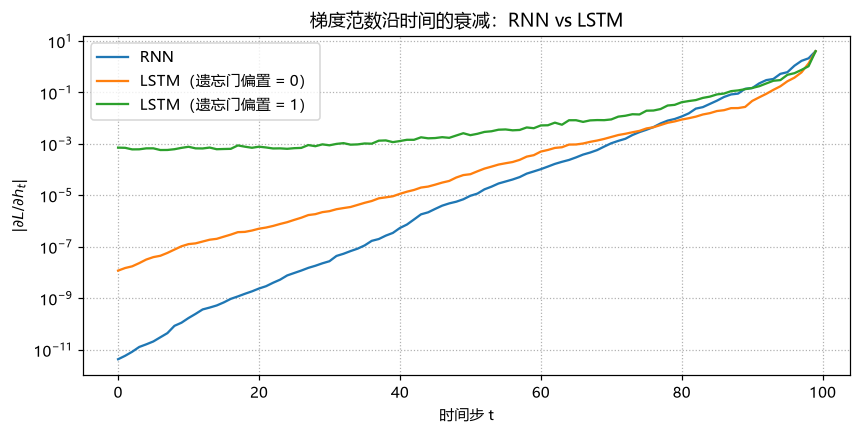

最早时刻 t=0 的梯度范数：
  RNN           : 4.238e-12
  LSTM (bias=0) : 1.183e-08
  LSTM (bias=1) : 7.150e-04


In [9]:
def curve_rnn(T=100, d=16, seed=7):
    """RNN：各时间步 h_t 的梯度范数（autograd 计算）"""
    torch.manual_seed(seed)
    W_xh = torch.randn(d, 1, dtype=DTYPE) * 0.5
    W_hh = torch.randn(d, d, dtype=DTYPE) * 0.2
    b_h = torch.zeros(d, dtype=DTYPE)
    x = (torch.randn(T, 1, 1, dtype=DTYPE) * 0.5).requires_grad_()

    h = torch.zeros(1, d, dtype=DTYPE)
    h_list = []
    for t in range(T):
        h = torch.tanh(x[t] @ W_xh.T + h @ W_hh.T + b_h)
        h_list.append(h)
    grads = torch.autograd.grad(h_list[-1].sum(), h_list)
    return torch.tensor([g.norm().item() for g in grads])


def curve_lstm(T=100, d=16, seed=7, forget_bias=0.0):
    """LSTM：同一协议下的梯度范数；forget_bias 控制遗忘门的初始偏置"""
    torch.manual_seed(seed)
    W_ih = torch.randn(4 * d, 1, dtype=DTYPE) * 0.3
    W_hh = torch.randn(4 * d, d, dtype=DTYPE) * 0.3
    b = torch.zeros(4 * d, dtype=DTYPE)
    b[d:2 * d] = forget_bias        # 第 2 段 = 遗忘门（i、f、g、o 顺序）
    x = (torch.randn(T, 1, 1, dtype=DTYPE) * 0.5).requires_grad_()

    h = torch.zeros(1, d, dtype=DTYPE)
    c = torch.zeros(1, d, dtype=DTYPE)
    h_list = []
    for t in range(T):
        gates = x[t] @ W_ih.T + h @ W_hh.T + b
        i, f, g, o = gates.chunk(4, dim=1)
        i, f, o = torch.sigmoid(i), torch.sigmoid(f), torch.sigmoid(o)
        g = torch.tanh(g)
        c = f * c + i * g
        h = o * torch.tanh(c)
        h_list.append(h)
    grads = torch.autograd.grad(h_list[-1].sum(), h_list)
    return torch.tensor([g.norm().item() for g in grads])


g_rnn = curve_rnn()
g_lstm = curve_lstm(forget_bias=0.0)
g_lstm_fb1 = curve_lstm(forget_bias=1.0)

plt.figure(figsize=(9, 4))
plt.semilogy(g_rnn.numpy(), label="RNN")
plt.semilogy(g_lstm.numpy(), label="LSTM（遗忘门偏置 = 0）")
plt.semilogy(g_lstm_fb1.numpy(), label="LSTM（遗忘门偏置 = 1）")
plt.xlabel("时间步 t")
plt.ylabel(r"$|\partial L/\partial h_t|$")
plt.title("梯度范数沿时间的衰减：RNN vs LSTM")
plt.legend()
plt.grid(True, which="both", ls=":")
plt.show()

print("最早时刻 t=0 的梯度范数：")
print(f"  RNN           : {g_rnn[0]:.3e}")
print(f"  LSTM (bias=0) : {g_lstm[0]:.3e}")
print(f"  LSTM (bias=1) : {g_lstm_fb1[0]:.3e}")

## 10. 用 LSTM 训练一个长依赖任务

任务：序列第 0 位是 $\pm 1$ 的**标记信号**，之后全是小噪声；要求模型在 $T=50$ 步之后还原这个标记（回归）。

能不能记住 50 步前的信息，正是普通 RNN 的软肋、LSTM 的优势场景。本实验把**总遗忘门偏置初始化为 2**，让训练初期的记忆通道更容易保持；这是为了让当前合成长依赖任务稳定收敛，并不是所有任务通用的固定取值。训练后用独立的 512 条样本报告验证 MSE 和符号准确率。

step 0   loss = 1.0153
step 399 loss = 0.000001


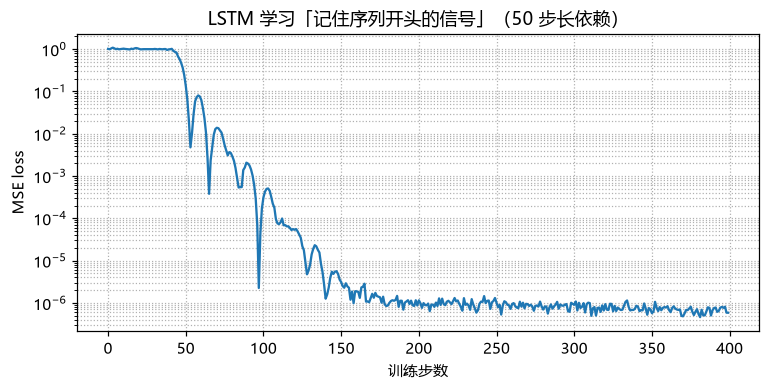

验证 MSE：0.000001
验证符号准确率：100.0%
前5条目标： [1.0, -1.0, 1.0, -1.0, -1.0]
前5条预测： [1.0, -1.001, 1.0, -1.0, -0.999]


In [10]:
torch.manual_seed(0)

T_train, B_train, hidden_train = 50, 64, 16
model_lstm = nn.LSTM(1, hidden_train, batch_first=True).to(DTYPE)
head = nn.Linear(hidden_train, 1).to(DTYPE)

# PyTorch 有两份偏置；这里令遗忘门的总偏置为 2.0
with torch.no_grad():
    model_lstm.bias_ih_l0[hidden_train:2 * hidden_train].fill_(2.0)
    model_lstm.bias_hh_l0[hidden_train:2 * hidden_train].zero_()
optimizer = torch.optim.Adam(list(model_lstm.parameters()) + list(head.parameters()), lr=1e-2)
loss_fn = nn.MSELoss()

hist = []
for step in range(400):
    # 任务：第 0 位是 ±1 标记，其后全是噪声；目标 = 还原第 0 位
    xb = torch.randn(B_train, T_train, 1, dtype=DTYPE) * 0.1
    marker = (2 * torch.randint(0, 2, (B_train, 1)) - 1).to(DTYPE)
    xb[:, 0, :] = marker

    out, _ = model_lstm(xb)
    pred = head(out[:, -1, :])
    loss = loss_fn(pred, marker)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    hist.append(loss.item())

print(f"step 0   loss = {hist[0]:.4f}")
print(f"step {len(hist) - 1} loss = {hist[-1]:.6f}")

plt.figure(figsize=(8, 3.5))
plt.plot(hist)
plt.yscale("log")
plt.xlabel("训练步数")
plt.ylabel("MSE loss")
plt.title("LSTM 学习「记住序列开头的信号」（50 步长依赖）")
plt.grid(True, which="both", ls=":")
plt.show()

# 独立验证集：报告整体指标，并展示前 5 条
model_lstm.eval()
head.eval()
with torch.no_grad():
    val_x = torch.randn(512, T_train, 1, dtype=DTYPE) * 0.1
    val_marker = (2 * torch.randint(0, 2, (512, 1)) - 1).to(DTYPE)
    val_x[:, 0, :] = val_marker
    val_pred = head(model_lstm(val_x)[0][:, -1, :])
    val_mse = loss_fn(val_pred, val_marker).item()
    sign_acc = (val_pred.sign() == val_marker).to(DTYPE).mean().item()

print(f"验证 MSE：{val_mse:.6f}")
print(f"验证符号准确率：{sign_acc:.1%}")
print("前5条目标：", val_marker[:5].flatten().tolist())
print("前5条预测：", [round(v, 3) for v in val_pred[:5].flatten().tolist()])

## 11. 多层与双向 LSTM 的维度说明及 PAD 处理

- **多层**（`num_layers=2`）：`output` 仍是**最后一层**的全部时间步 $(B, T, d)$；而 `h_n` / `c_n` 第一维变成 `2`（每层一个），形状 $(2, B, d)$；
- **双向**（`bidirectional=True`）：`output` 变为 $(B, T, 2d)$（正向、反向拼接）；`h_n` / `c_n` 第一维 = 层数 × 2，顺序为 `[正1, 反1, 正2, 反2, ...]`；
- **双向整句表示**：`output[:, -1]` 的反向部分只处理了原序列最后一个位置，并不是反向网络读完整句子的最终状态。应将 `h_n` 重排为 `(层数, 方向数, B, d)`，再拼接顶层正向和反向最终状态；
- **层间 Dropout**：`nn.LSTM(..., num_layers=L, dropout=p)` 只在相邻 LSTM 层之间应用 Dropout；`num_layers=1` 时内置 Dropout 不生效；
- **PAD**：对单向 RNN/LSTM，`output[:, -1]` 可能落在填充位，可按真实长度取 `output[b, lengths[b]-1]`。更通用的做法是用 `pack_padded_sequence` 跳过 PAD；逐时间步损失也必须用 mask 排除 PAD 标签。

In [11]:
B2, T2, n2, d2 = 4, 6, 5, 3
x2 = torch.randn(B2, T2, n2, dtype=DTYPE)
lengths = torch.tensor([6, 4, 2, 1])           # 各序列真实长度（降序，便于 pack）

# 多层单向
lstm2 = nn.LSTM(n2, d2, num_layers=2, batch_first=True).to(DTYPE)
out2, (h2, c2) = lstm2(x2)
print("2 层单向：output", tuple(out2.shape), "| h_n", tuple(h2.shape), "| c_n", tuple(c2.shape))

# 多层双向
lstm_bi = nn.LSTM(n2, d2, num_layers=2, batch_first=True, bidirectional=True).to(DTYPE)
out_bi, (h_bi, c_bi) = lstm_bi(x2)
print("2 层双向：output", tuple(out_bi.shape), "| h_n", tuple(h_bi.shape), "| c_n", tuple(c_bi.shape))

# h_n 顺序是 [第1层正向, 第1层反向, 第2层正向, 第2层反向]
h_bi_by_layer = h_bi.view(2, 2, B2, d2)
sentence_bi = torch.cat([h_bi_by_layer[-1, 0], h_bi_by_layer[-1, 1]], dim=-1)
print("顶层双向整句表示：", tuple(sentence_bi.shape))

# 取最后有效状态：按长度索引，而不是 output[:, -1]
lstm1 = nn.LSTM(n2, d2, batch_first=True).to(DTYPE)
out1, _ = lstm1(x2)
idx = (lengths - 1).clamp(min=0)
last_valid = out1[torch.arange(B2), idx]
print("\n按长度索引的最后有效状态:", tuple(last_valid.shape))

# 或使用 pack_padded_sequence（跳过 PAD，避免用到填充位的结果）
packed = nn.utils.rnn.pack_padded_sequence(x2, lengths, batch_first=True, enforce_sorted=True)
out_packed, (h_packed, c_packed) = lstm1(packed)
unpacked, out_lens = nn.utils.rnn.pad_packed_sequence(out_packed, batch_first=True, total_length=T2)
print("pack/unpack 输出:", tuple(unpacked.shape), "| 各序列长度:", out_lens.tolist())
print("按长度索引 == packed h_n：", torch.allclose(last_valid, h_packed[-1], atol=1e-12))

2 层单向：output (4, 6, 3) | h_n (2, 4, 3) | c_n (2, 4, 3)
2 层双向：output (4, 6, 6) | h_n (4, 4, 3) | c_n (4, 4, 3)
顶层双向整句表示： (4, 6)

按长度索引的最后有效状态: (4, 3)
pack/unpack 输出: (4, 6, 3) | 各序列长度: [6, 4, 2, 1]
按长度索引 == packed h_n： True


## 12. 接回文本任务：Embedding → LSTM → 分类

真实文本不会直接以随机浮点序列进入 LSTM，而是先经过词表映射和 Embedding：

```text
文本 → 词 ID (B,T) → Embedding (B,T,n) → pack → LSTM → 整句向量 → Linear → logits
```

下面用双向 LSTM 演示完整形状链。`padding_idx=0` 让 PAD 对应的词向量保持为零；`pack_padded_sequence` 让循环层跳过补齐位置；分类训练时把 `logits` 直接交给 `CrossEntropyLoss`，不需要预先做 softmax。

In [12]:
class LSTMTextClassifier(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_size, num_classes, pad_idx=0):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=pad_idx)
        self.lstm = nn.LSTM(
            embedding_dim, hidden_size, batch_first=True, bidirectional=True
        )
        self.classifier = nn.Linear(2 * hidden_size, num_classes)

    def forward(self, token_ids, lengths):
        vectors = self.embedding(token_ids)                     # (B, T, embedding_dim)
        packed = nn.utils.rnn.pack_padded_sequence(
            vectors, lengths.cpu(), batch_first=True, enforce_sorted=False
        )
        _, (h_n, _) = self.lstm(packed)                         # (2, B, hidden_size)
        forward_final, backward_final = h_n[0], h_n[1]
        sentence_vector = torch.cat([forward_final, backward_final], dim=-1)
        return self.classifier(sentence_vector)                 # (B, num_classes)


token_ids = torch.tensor([
    [1, 2, 3, 4],
    [5, 6, 0, 0],
    [7, 0, 0, 0],
])
lengths = torch.tensor([4, 2, 1])

text_model = LSTMTextClassifier(
    vocab_size=20, embedding_dim=8, hidden_size=6, num_classes=3, pad_idx=0
).to(DTYPE)
text_logits = text_model(token_ids, lengths)

print("词 ID：", tuple(token_ids.shape))
print("分类 logits：", tuple(text_logits.shape))
print("PAD 向量保持为零：", torch.count_nonzero(text_model.embedding.weight[0]).item() == 0)


词 ID： (3, 4)
分类 logits： (3, 3)
PAD 向量保持为零： True
